# Ex. 9.4
# a)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(seed=42)

In [ ]:
df = pd.read_csv("../../Datasets_from_the_book/salmon.dat", sep="\s+", dtype=np.float64)
categories = df.columns.tolist()
data = df.to_numpy()

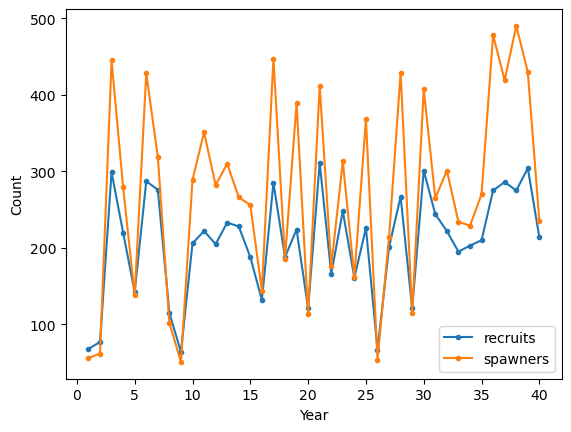

In [137]:
years = data[:,0]
R = data[:,1]
S = data[:,2]

plt.plot(years, R, ".-", label=categories[1])
plt.plot(years, S, ".-", label=categories[2])
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

Given the **Beverton-Holt** model:
$$
R = \frac{1}{\beta_1 + \beta_2/S}
$$

we can use the transformed variables $R = 1/r$ and $S = 1/s$, and rewrite the expression:
$$
\frac{1}{r} = \frac{1}{\beta_1 + \beta_2/\frac{1}{s}}
$$

$$
\frac{1}{r} = \frac{1}{\beta_1 + \beta_2 s}
$$

$$
r = \beta_1 + \beta_2 s
$$

Now we can find the parameters with linear regression, having $r = 1/R$ and $s = 1/S$.

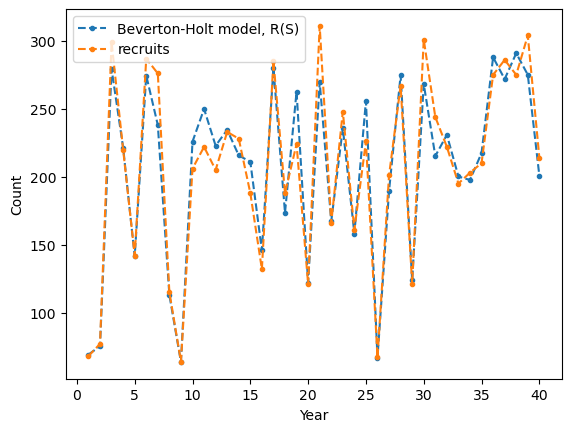

In [261]:
def beverton_holt_model(beta1, beta2, S):
    R = 1.0/(beta1 + (beta2/S))
    return R

r = 1/R
s = 1/S
r = r.reshape(-1,1)
s = s.reshape(-1,1)

model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
beta2 = model.coef_
beta1 = model.intercept_

plt.plot(years, beverton_holt_model(beta1, beta2, S).ravel(), ".--", label="Beverton-Holt model, R(S)")
plt.plot(years, R, ".--", label=categories[1])
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

If $R = S$, we have:
$$
R = \frac{1}{\beta_1 + \beta_2/R}
$$

$$
R(\beta_1 + \beta_2/R) = 1
$$

$$
R\beta_1 + \beta_2 = 1
$$

$$
R = S = \frac{1 - \beta_2}{\beta_1}
$$

In [215]:
RS_opti = ((1- beta2)/beta1).item()
print(RS_opti)
print(beverton_holt_model(beta1, beta2, RS_opti).item())

150.0976343009786
150.0976343009786


In [350]:
print(beta1)
print(beta2)

[66.67055459]
[[0.51403498]]


# Bootstrapping residuals

In [349]:
R = R.reshape(-1,1)
S = S.reshape(-1,1)

n_bootstraps = 1000
n_samples_per_bootstrap = len(R)
bootstraps_res = np.zeros([n_bootstraps, n_samples_per_bootstrap])

model = LinearRegression(fit_intercept=True).fit(X=S, y=R)
predictions = model.predict(S)
residues = R - predictions

for i in range(n_bootstraps):
    bootstraps_res[i,:] = rng.choice(residues, size=len(residues.ravel()), replace=True).reshape(1,-1)

bootstraps_betas = np.zeros([n_bootstraps, 2])
Y = predictions.reshape(1,-1) + bootstraps_res

for i in range(n_bootstraps):
    new_model = LinearRegression(fit_intercept=True).fit(X=S, y=Y[i,:])
    new_predictions = new_model.predict(S)
    bootstraps_betas[i,0] = new_model.intercept_.item()
    bootstraps_betas[i,1] = new_model.coef_.item()

In [348]:
np.mean(bootstraps_betas, axis=0)

array([66.76712901,  0.51393954])

# Bootstrapping cases

In [324]:
n_bootstraps = 1000
n_samples_per_bootstrap = len(S)
bootstraps = np.zeros([n_bootstraps, n_samples_per_bootstrap])

for i in range(n_bootstraps):
    bootstraps[i,:] = rng.choice(s, size=n_samples_per_bootstrap, replace=True).reshape(1,-1)

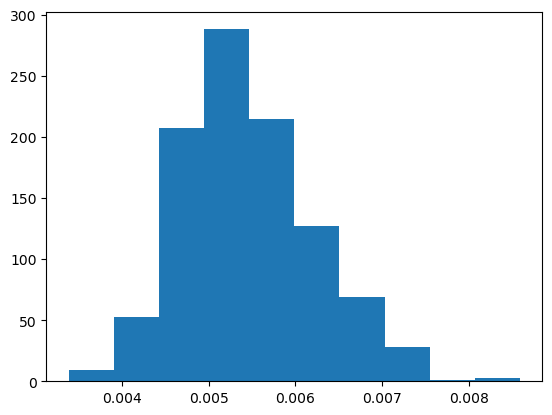

In [325]:
mean_bootstraps = np.mean(bootstraps, axis=1)
plt.hist(mean_bootstraps)
plt.show()

In [326]:
np.mean(mean_bootstraps)

np.float64(0.005446905939275988)

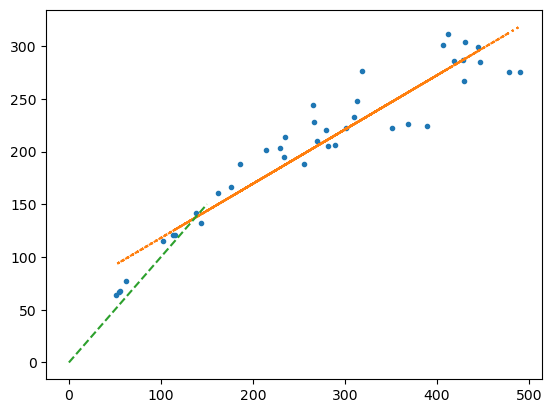

In [327]:
model_R_S = LinearRegression(fit_intercept=True).fit(X=S.reshape(-1,1), y=R.reshape(-1,1))
plt.plot(S,R,".")
plt.plot(S, model_R_S.predict(S.reshape(-1,1)), ":")
plt.plot([0, 150], [0, 150], "--")